# Workflow para investigación de pensiones — Premio Amafore-ITAM 2026

**Pregunta**: ¿Cómo se relacionan los aportes al SAR con la realidad económica de los hogares mexicanos?

Este notebook expone el flujo cross-dataset que el observatorio publica como insumo para investigación sobre pensiones mexicanas. Combina los tres datasets principales (CDMX × CONSAR × ENIGH) más los endpoints comparativos editoriales del namespace `comparativo`.

## Setup completo

In [1]:
from datetime import date

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from datos_mexico import DatosMexico

client = DatosMexico()

## 1. Endpoint estrella: aportes vs jubilaciones actuales

Cruza deducciones actuales del servidor CDMX activo con jubilaciones actuales recibidas por hogares ENIGH. Incluye texto interpretativo del observatorio aclarando qué se puede y qué NO se puede concluir.

In [2]:
apo = client.comparativo.aportes_vs_jubilaciones_actuales()
print("=== CDMX (deducciones actuales del servidor activo) ===")
print(f"  Servidores en padrón: {apo.cdmx_aportes_actuales.n_servidores:,}")
print(f"  Sueldo bruto medio:   ${apo.cdmx_aportes_actuales.mean_sueldo_bruto:,.2f}")
print(f"  Sueldo neto medio:    ${apo.cdmx_aportes_actuales.mean_sueldo_neto:,.2f}")
print(f"  Deducción media:      ${apo.cdmx_aportes_actuales.mean_deduccion_total:,.2f}")
print(f"  % deducción / bruto:  {apo.cdmx_aportes_actuales.pct_deduccion_sobre_bruto:.2f}%")
print()
print("=== ENIGH (jubilaciones actuales recibidas por hogares) ===")
print(f"  Hogares con jubilación (expandidos): {apo.enigh_jubilaciones_actuales.n_hogares_con_jubilacion_expandido:,}")
print(f"  % hogares con jubilación: {apo.enigh_jubilaciones_actuales.pct_hogares_con_jubilacion:.2f}%")
print(f"  Jubilación media trim (solo jubilados): ${apo.enigh_jubilaciones_actuales.mean_jubilacion_solo_jubilados_trim:,.2f}")
print(f"  Jubilación media mensual (solo jubilados): ${apo.enigh_jubilaciones_actuales.mean_jubilacion_solo_jubilados_mensual:,.2f}")

=== CDMX (deducciones actuales del servidor activo) ===
  Servidores en padrón: 246,829
  Sueldo bruto medio:   $13,225.41
  Sueldo neto medio:    $11,796.04
  Deducción media:      $1,429.37
  % deducción / bruto:  8.04%

=== ENIGH (jubilaciones actuales recibidas por hogares) ===
  Hogares con jubilación (expandidos): 7,169,614
  % hogares con jubilación: 18.46%
  Jubilación media trim (solo jubilados): $33,817.81
  Jubilación media mensual (solo jubilados): $11,272.60


### Campos editoriales del payload

Este endpoint del namespace `comparativo` viene con dos campos de texto pre-escritos por el equipo del observatorio:

- `interpretacion`: lectura sugerida del cruce.
- `caveats`: lista de advertencias metodológicas.

El SDK los preserva sin alteración (son contenido humano, no transformaciones). El usuario debe leerlos cuidadosamente.

In [3]:
print("INTERPRETACIÓN OFICIAL DEL OBSERVATORIO:\n")
print(apo.interpretacion)
print("\n\nCAVEATS:")
for i, c in enumerate(apo.caveats, 1):
    print(f"\n{i}. {c}")

INTERPRETACIÓN OFICIAL DEL OBSERVATORIO:

Mensualmente, un servidor CDMX activo aporta ~$1,429 en deducciones totales (promedio) — este monto INCLUYE ISR + IMSS/ISSSTE + SAR + otras, sin separación a nivel registro. Simultáneamente, 18.5% de los hogares nacionales reciben jubilación, con promedio trimestral $33,818 ($11,273/mes) solo para quienes la reciben. Son dos realidades coexistentes del sistema de pensiones, no un gap actuarial predictivo.


CAVEATS:

1. cdmx.nombramientos es snapshot sin fecha alta/baja. Incluye todos los registros disponibles sin filtro temporal (246,841 registros, 1 por persona).

2. cdmx.nombramientos.deducciones (bruto - neto) es el agregado total: INCLUYE ISR + IMSS/ISSSTE + SAR + créditos personales + otras deducciones sin separación posible a nivel registro. Usarla como proxy de 'aporte a pensión' sobreestima el aporte real.

3. ENIGH.jubilaciones son pensiones CURRENTLY cobradas por hogares del universo ENIGH 2024 NS (18.5% de hogares), no proyección de

## 2. Cobertura PEA del SAR (cotizantes vs Población Económicamente Activa)

Serie **anual** que reporta: cotizantes en AFORE, PEA total y el porcentaje que representa la cobertura del SAR sobre la PEA.

In [4]:
pea = client.consar.pea_cotizantes_serie()
df_pea = pd.DataFrame(
    [
        {
            "anio": p.anio,
            "cotizantes": p.cotizantes,
            "pea": p.pea,
            "pct_pea_afore": float(p.porcentaje_pea_afore),
            "brecha_no_cubierta_pct": float(p.brecha_no_cubierta_pct),
        }
        for p in pea.serie
    ]
)
print(f"Cobertura mín: {pea.cobertura_min_pct:.2f}% en {pea.cobertura_min_anio}")
print(f"Cobertura máx: {pea.cobertura_max_pct:.2f}% en {pea.cobertura_max_anio}")
df_pea.tail(10)

Cobertura mín: 40.40% en 2011
Cobertura máx: 48.40% en 2018


,anio,cotizantes,pea,pct_pea_afore,brecha_no_cubierta_pct
5,2015,24142279,53809017,44.90,55.10
6,2016,24903688,54034800,46.10,53.90
7,2017,25994436,54696638,47.50,52.50
8,2018,27118739,56023199,48.40,51.60
9,2019,27064027,57277858,47.30,52.70
10,2020,26115738,55880916,46.70,53.30
11,2021,26459961,58761793,45.00,55.00
12,2022,28770238,60145456,47.83,52.17
13,2023,29006508,61042968,47.52,52.48
14,2024,29119328,61055321,47.69,52.31


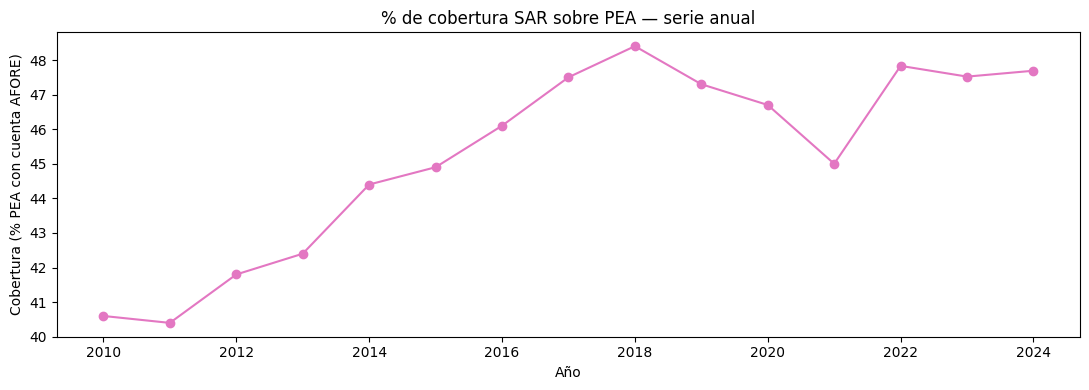

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df_pea["anio"], df_pea["pct_pea_afore"], marker="o", color="#e377c2")
ax.set_title("% de cobertura SAR sobre PEA — serie anual")
ax.set_xlabel("Año")
ax.set_ylabel("Cobertura (% PEA con cuenta AFORE)")
fig.tight_layout()
plt.show()

## 3. Decil del servidor CDMX vs hogares ENIGH

El observatorio mapea los percentiles del sueldo del servidor CDMX a los deciles del hogar ENIGH bajo varios escenarios (perceptor único, dos perceptores). Incluye narrativa estructurada en `caveats_interpretativos` para evitar simplificaciones.

In [6]:
dec = client.comparativo.decil_servidores_cdmx()
print("NARRATIVA:\n")
print(dec.narrative)
print("\n\nCAVEATS INTERPRETATIVOS:")
print("\n· frontera_p50:        ", dec.caveats_interpretativos.frontera_p50)
print("\n· narrativa_correcta:  ", dec.caveats_interpretativos.narrativa_correcta)
print("\n· insight_principal:   ", dec.caveats_interpretativos.insight_principal)
print("\n· implicacion_narrativa:", dec.caveats_interpretativos.implicacion_narrativa)

NARRATIVA:

Bajo Escenario A (servidor CDMX como perceptor único), el servidor mediano (sueldo $10,410/mes) cae en el decil 2 de ingresos hogar nacional. Bajo Escenario B (servidor + perceptor mediano asalariado $7,869/mes), el hogar total $18,279/mes cae en el decil 5. La diferencia entre escenarios refleja el peso relativo del perceptor adicional; ambos escenarios son conservadores porque omiten transferencias, rentas y otros componentes del ing_cor ENIGH.


CAVEATS INTERPRETATIVOS:

· frontera_p50:         Mediana CDMX $10,410 cae a $463 del boundary d2/d3 (upper d2 = $10,873). Pequeña variación en distribución CDMX reclasificaría narrativa.

· narrativa_correcta:   Servidor mediano CDMX está EN FRONTERA d2/d3 nacional, no firmemente dentro de d2.

· insight_principal:    La posición socioeconómica del hogar depende más de COMPOSICIÓN (número de perceptores) que del salario individual. Agregar un perceptor mediano nacional al servidor mediano CDMX mueve el hogar 3 deciles arriba (d2

## 4. Comparativo CDMX vs nacional: ingreso

El sueldo medio del servidor público CDMX vs el ingreso medio del hogar nacional / hogar CDMX (ENIGH).

In [7]:
ing = client.comparativo.ingreso_cdmx_vs_nacional()
print("Servidor CDMX:")
print(f"  N: {ing.cdmx_servidor.n_servidores:,}")
print(f"  Sueldo bruto medio mensual: ${ing.cdmx_servidor.mean_sueldo_bruto_mensual:,.2f}")
print()
print("Hogar nacional ENIGH:")
print(f"  N: {ing.enigh_hogar_nacional.n_hogares_expandido:,}")
print(f"  Ingreso corriente medio mensual: ${ing.enigh_hogar_nacional.mean_ing_cor_mensual:,.2f}")
print()
print("Hogar CDMX ENIGH:")
print(f"  N: {ing.enigh_hogar_cdmx.n_hogares_expandido:,}")
print(f"  Ingreso corriente medio mensual: ${ing.enigh_hogar_cdmx.mean_ing_cor_mensual:,.2f}")
print()
print(f"Ratio hogar nacional / servidor: {ing.ratio_hogar_nacional_sobre_servidor:.3f}")
print(f"Ratio hogar CDMX / servidor:     {ing.ratio_hogar_cdmx_sobre_servidor:.3f}")
print("\nNota del observatorio:")
print(ing.note)

Servidor CDMX:
  N: 246,831
  Sueldo bruto medio mensual: $13,225.47

Hogar nacional ENIGH:
  N: 38,830,230
  Ingreso corriente medio mensual: $25,954.61

Hogar CDMX ENIGH:
  N: 3,082,330
  Ingreso corriente medio mensual: $36,894.95

Ratio hogar nacional / servidor: 1.962
Ratio hogar CDMX / servidor:     2.790

Nota del observatorio:
Brechas calculadas vs mean_servidor_bruto como base. Las unidades difieren (persona individual vs hogar con múltiples miembros), por lo que la 'brecha' no es equivalente a desigualdad entre personas. Un hogar ENIGH promedio tiene 3.35 personas y combina salarios + pensiones + transferencias + rentas + actividad económica.


## 5. Lo que se puede argumentar con estos datos

Estos datos permiten afirmaciones **descriptivas** sobre el momento actual:

- Cobertura observada del SAR sobre la PEA.
- Magnitud relativa entre deducciones del servidor CDMX activo y   jubilaciones efectivamente recibidas por hogares ENIGH.
- Posición del sueldo del servidor CDMX dentro de la distribución   de ingresos de hogares mexicanos bajo un escenario explícito de   composición del hogar.
- Composición del SAR por AFORE y por componente.

## 6. Lo que NO se puede concluir

- **Suficiencia de pensiones futuras**: ningún dato pasado predice la pensión que recibirá un trabajador específico al retirarse. Eso requiere proyección actuarial con supuestos sobre rendimientos, salario de referencia, antigüedad y reglas vigentes en el momento del retiro.
- **Cobertura PEA ≠ tasa de reemplazo**: la cobertura indica cuántos trabajadores cotizan; la tasa de reemplazo es el % del salario de referencia que recibirán como pensión. Son métricas diferentes.
- **El SAR es solo una pieza del sistema**: existen también PensionISSSTE, pensiones contributivas previas (IMSS-1973, ISSSTE-pre-2007), programas asistenciales (Pensión para el Bienestar de Personas Adultas Mayores), y esquemas privados.
- **El cruce CDMX–ENIGH no es causal**: el servidor CDMX no es una muestra aleatoria de la población; sus deducciones reflejan su régimen específico (ISSSTE en muchos casos), no el agregado del país.

## Citación sugerida

Si usas el observatorio en un paper, citarnos así:

```bibtex
@software{datos_mexico_py,
  author  = {{Equipo de Datos México}},
  title   = {datos-mexico-py: Cliente Python para la API del Observatorio Datos México},
  year    = {2026},
  url     = {https://github.com/Datos-Mexico/datos-mexico-py},
  version = {0.1.0}
}
```

In [8]:
client.close()